# Chapter 10. 분류 분석으로 주문 취소 여부 예측하기

이 Notebook은 "Chapter 10 실습 진행 가이드. 분류 분석으로 주문 취소 여부 예측하기"를 따라가면서, 실제로 AI(LLM)에게 무엇을 물어봤고 어떤 설명을 이해했고 실행 결과가 어떻게 나왔는지를 한 단계씩 남긴 기록입니다.

Chapter09에서는 숫자(order_total)를 예측했는데, 이번엔 Yes/No에 가까운 문제입니다 — **이 주문이 나중에 취소(cancelled)될지 완료(completed)될지**를 주문이 막 들어온 시점에 미리 가늠해봅니다.

이 Notebook의 핵심은 높은 accuracy를 만드는 것이 아니라 다음 순서를 지키는 것입니다.

`타깃 정의 → 예측 시점 → Feature Leakage Audit → 주문 단위 특징 생성 → 병합 검증 → 클래스 분포 → Train/Validation/Test → Pipeline → Validation 모델 선택 → Validation Threshold 선택 → Final Test → FP/FN 해석 → Privacy-safe Output → Validation Evidence`

**모델과 Threshold 선택은 Validation에서 끝내고, Final Test는 모든 선택이 끝난 뒤 마지막 평가에만 사용합니다.**

## 제출 정보
- 이름: 조영우
- GitHub ID: `cyw0927`
- 작성일: 2026-09-29
- 최종 Notebook URL:

```text
https://github.com/cyw0927/-llm-data-analysis-course/blob/main/assignments/chapter10/chapter10.ipynb
```


## 실습 0. 실행 환경 확인하고 Chapter10 입력 준비하기

### AI에게 질문

> Chapter10에서는 주문이 취소될지 완료될지를 예측하려고 합니다. Chapter08·09에서 썼던 공통 프로젝트 데이터(`data/raw`)를 그대로 쓰면 될까요? Notebook이 프로젝트 루트를 잘 찾는지도 확인하고 싶습니다.

### 초보자 상세 설명

가이드에 이렇게 되어 있었습니다.

> Chapter10은 Chapter05의 오류 탐지용 전용 Raw를 모델링 입력으로 사용하지 않습니다. Chapter08·09와 같은 공통 프로젝트 데이터 흐름을 이어받습니다.

그래서 이번에도 `data/raw/customers.csv`, `orders.csv`, `order_items.csv`를 그대로 씁니다. 먼저 터미널에서 아래 명령을 한 번 실행해서 FK 관계 검증까지 통과한 입력을 `data/processed/`에 준비해 둡니다.

```powershell
python scripts/prepare_ch10_data.py
```

이번 장도 Chapter09처럼 `src/classification.py`라는 공용 코드를 새로 만들어서, 타깃 생성부터 Validation Evidence까지 재사용 가능한 함수로 정리해 뒀습니다. 이 Notebook에서는 그 함수들을 불러와서 씁니다.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

def find_project_root(start: Path) -> Path:
    """현재 Notebook 위치와 상관없이 저장소 루트를 찾습니다."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"

print("Python 실행 파일:", sys.executable)
print("PROJECT_ROOT:", PROJECT_ROOT)


Python 실행 파일: C:\Users\dkrak\AppData\Local\Programs\Python\Python314\python.exe
PROJECT_ROOT: C:\dev\llm-data-analysis-course


In [2]:
import sklearn

print("numpy 버전:", np.__version__)
print("pandas 버전:", pd.__version__)
print("scikit-learn 버전:", sklearn.__version__)

from src.classification import (
    FEATURE_COLUMNS,
    FORBIDDEN_FEATURES,
    TARGET_COLUMN,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    build_classification_dataset,
    build_confusion_matrix,
    build_confusion_matrix_grid,
    plot_confusion_matrix,
    plot_target_distribution,
    plot_validation_comparison,
    plot_threshold_curve,
    build_data_quality_checks,
    build_feature_audit,
    build_leakage_checklist,
    build_merge_checks,
    build_classification_validation,
    build_split_summary,
    build_target_distribution,
    create_prediction_result,
    cross_validate_on_validation,
    load_classification_source_data,
    make_classification_models,
    public_prediction_result,
    run_classification_analysis,
    save_classification_outputs,
    select_model_from_validation,
    select_threshold_from_validation,
    split_train_val_test,
    train_and_evaluate_final,
    validate_feature_columns,
)

print("src.classification에서 함수 불러오기 성공")


numpy 버전: 2.5.1
pandas 버전: 3.0.5
scikit-learn 버전: 1.9.0
src.classification에서 함수 불러오기 성공


### Windows DLL 차단 환경 대응 (Chapter07·09와 같은 문제)

이 PC의 기본 Python(3.12) 환경에서는 scikit-learn이 SciPy DLL을 불러오다가 Windows 애플리케이션 제어 정책에 막힙니다. Chapter09 때 등록해 둔 Python 3.14 커널(`py314-regression`)에서는 같은 코드가 정상 동작해서, 이번 Chapter도 그 커널로 실행했습니다. 위 셀에서 `sys.executable`이 `Python314` 경로로 나오는지 먼저 확인하는 것이 이번 실습의 첫 번째 체크포인트입니다.

### 실습 0 결과 확인 및 정리

- `PROJECT_ROOT`가 저장소 최상위 폴더로 정상 표시되었습니다.
- `scikit-learn`과 `src.classification` import가 모두 에러 없이 끝났습니다.
- `python scripts/prepare_ch10_data.py`도 미리 실행해서 FK 관계 검증(orders↔customers, order_items↔orders, order_items↔products)이 모두 PASS인 것을 확인했습니다.


## 실습 1. Target Contract와 예측 시점 정의하기

### AI에게 질문

> 주문 데이터에서 완료(completed)와 취소(cancelled) 상태만 남겨서 취소 여부를 예측하려고 합니다. 예측 시점에 쓰면 안 되는 컬럼이 뭔지 정리해 주세요.

### 초보자 상세 설명

이번 타깃은 딱 두 상태만 씁니다.

- `completed` → 0
- `cancelled` → 1
- `refunded`(그리고 그 외 상태) → **모델링 대상에서 아예 제외**

가이드에서 강조한 부분은 이거였습니다.

> 예측 시점에 이미 알 수 있는 정보는 무엇인가? 그 시점 이후에만 알 수 있어 제외해야 하는 정보는 무엇인가?

이번 교육용 가정은 **주문 생성 직후**입니다. 그래서 `order_status`(취소/환불 여부가 이미 확정된 값), `is_cancelled`(타깃 자체), `order_id`/`customer_id`/`product_id`(식별자)는 전부 금지 목록입니다.

한 가지 Chapter09와 다른 점이 있었습니다. Chapter09에서는 `order_total`(주문 금액)이 타깃이라서 수량·단가 정보를 금지했는데, 이번엔 타깃이 "취소 여부"라서 오히려 **주문 규모(품목 수, 수량, 금액)가 유용한 feature**가 될 수 있습니다. 이 값들은 주문이 생성되는 순간 이미 확정되는 정보(장바구니 내용)이지 취소 여부가 확정된 뒤에 생기는 정보가 아니기 때문입니다.


한 가지 더, 이번엔 처음부터 feature를 3개 더 추가해서 시작합니다: 장바구니에 담긴 카테고리 다양성(`category_count`), 가장 많이 담은 카테고리(`dominant_category`), 그리고 고객이 가입한 뒤 며칠 만에 이 주문을 했는지(`customer_tenure_days`)입니다. 마지막 tenure 특징은 실제로 데이터를 만들어보다가 재미있는(?) 문제를 하나 발견해서, 실습 3에서 자세히 다룹니다.

In [3]:
print("Target:", TARGET_COLUMN)
print("Allowed features:", FEATURE_COLUMNS)
print("Forbidden features:", sorted(FORBIDDEN_FEATURES))

validate_feature_columns()
print("Feature leakage gate: PASS")


Target: is_cancelled
Allowed features: ['order_month', 'order_dayofweek', 'age', 'item_count', 'total_quantity', 'order_amount', 'category_count', 'customer_tenure_days', 'payment_method', 'gender', 'city', 'dominant_category']
Forbidden features: ['cancel_reason', 'cancelled_at', 'customer_id', 'is_cancelled', 'order_id', 'order_status', 'product_id']
Feature leakage gate: PASS


### 실습 1 결과 확인 및 정리

## 예측 문제 정의
- Target: `is_cancelled` (completed=0, cancelled=1, refunded/기타 상태는 모델링 대상에서 제외)
- 예측 단위: 주문 1건
- 예측 시점: 주문이 생성된 직후 — 주문 메타데이터, 고객의 비식별 특성, 그리고 이번 주문의 품목 수/수량/금액은 알고 있지만, 이 주문이 나중에 어떻게 처리될지(완료/취소)는 아직 모르는 시점
- 예측 시점에 알 수 있는 정보: `order_month`, `order_dayofweek`, `payment_method`, `age`, `gender`, `city`, `item_count`, `total_quantity`, `order_amount`, `category_count`, `dominant_category`, `customer_tenure_days`
- 예측 시점에 알 수 없는(사용 금지) 정보: `order_status`, `is_cancelled`, `order_id`, `customer_id`, `product_id`, `cancel_reason`, `cancelled_at`

### 나의 해석과 판단
Chapter09에서는 "주문 금액을 예측하니까 수량·단가는 금지"였는데, 이번엔 "취소 여부를 예측하니까 수량·단가로 만든 주문 규모는 오히려 사용 가능"이라는 점이 헷갈릴 뻔했습니다. 결국 기준은 "이 값이 예측 시점에 이미 확정되어 있는가"이지, "이 값이 주문 상세에서 왔는가"가 아니라는 걸 이번에 다시 확인했습니다.


## 실습 2. 주문 단위 특징과 계산 관계 검증하기

### AI에게 질문

> `order_items`를 주문 단위로 집계해서 품목 수, 총 수량, 주문 금액을 만들어 주세요. 그리고 `line_total = quantity * unit_price`가 실제로 맞는지도 확인해 주세요.

### 초보자 상세 설명

예측 단위가 주문 1건이므로, `order_items`(주문 상세, 여러 행)를 주문 하나당 1행으로 요약해야 합니다.

- `item_count` = 그 주문에 담긴 상품 종류 수
- `total_quantity` = 그 주문의 총 수량 합
- `order_amount` = 그 주문의 총 금액 합(`line_total`의 합)

Chapter09에서 배운 것처럼, 저장된 `line_total`이 있어도 그대로 믿지 않고 `quantity * unit_price`와 실제로 같은지부터 확인합니다. `src/classification.py`의 `build_order_item_features` 안에 이 검증이 들어 있어서, 불일치가 있으면 계산 대신 바로 에러가 나도록 만들어 뒀습니다.


In [4]:
data = load_classification_source_data(PROCESSED_DIR)
for name, frame in data.items():
    print(name, frame.shape)

model_data = build_classification_dataset(
    customers=data["customers"],
    orders=data["orders"],
    order_items=data["order_items"],
    products=data["products"],
)
display(model_data.head())
print("모델링 대상 주문 수(completed+cancelled):", len(model_data))


customers (150, 6)
orders (300, 7)
order_items (764, 6)
products (100, 4)


,order_id,customer_id,order_date,payment_method,order_status,order_month,order_dayofweek,item_count,total_quantity,order_amount,category_count,dominant_category,gender,age,city,customer_tenure_days,is_cancelled
0,238,124,2025-07-09,bank_transfer,completed,7,2,2,7,361000,2,도서,M,67,대구,288.0,0
1,12,98,2025-07-12,kakao_pay,completed,7,5,2,6,444000,2,전자기기,F,61,인천,247.0,0
2,169,9,2025-07-12,kakao_pay,completed,7,5,1,4,448000,1,생활용품,M,69,서울,NaN,0
3,97,11,2025-07-14,bank_transfer,cancelled,7,0,3,5,276000,3,식품,M,35,대구,NaN,1
4,61,4,2025-07-19,bank_transfer,completed,7,5,3,6,603000,3,생활용품,F,55,울산,NaN,0


모델링 대상 주문 수(completed+cancelled): 248


In [5]:
data_quality_checks = build_data_quality_checks(
    data["order_items"], customers=data["customers"], orders=data["orders"]
)
display(data_quality_checks)


,check,failing_rows
0,quantity_positive,0
1,unit_price_positive,0
2,line_total_matches_quantity_times_unit_price,0
3,signup_date_after_order_date (customer_tenure_...,56


### 실습 2 결과 확인 및 정리

## Target 생성과 계산 관계 검증
- item_count 계산식: 주문 1건에 속한 order_items 행 수
- total_quantity 계산식: 주문 1건의 quantity 합
- order_amount 계산식: 주문 1건의 line_total 합 (line_total = quantity × unit_price로 먼저 검증)
- quantity/unit_price 0 이하 건수: 0건
- line_total 불일치 건수: 0건 (불일치가 있었다면 `build_order_item_features`가 예외를 던져서 이 셀 자체가 실행되지 않았을 것입니다)
- 원본 orders: 300건 → completed(184) + cancelled(64) = **모델링 대상 248건** (refunded 52건은 제외)


추가로 만든 feature도 같은 방식으로 검증했습니다.
- category_count 계산식: 주문에 담긴 상품들의 서로 다른 카테고리 개수
- dominant_category 계산식: 주문에서 수량이 가장 많은 카테고리(동률이면 이름순으로 하나 고정)
- 이 둘도 `order_items` + `products`만으로 만들 수 있어서, item_count/total_quantity/order_amount와 같은 이유로 예측 시점에 이미 확정된 정보입니다.


## 실습 3. 병합 관계와 Feature Audit 확인하기

### AI에게 질문

> orders와 주문 특징, orders와 customers를 병합할 때 관계가 깨지지 않는지 확인하고, 최종적으로 어떤 feature를 쓰고 어떤 feature를 금지했는지 표로 정리해 주세요.

### 초보자 상세 설명

기대하는 관계는 두 가지입니다.

- `orders` ↔ `order_item_features` = `one_to_one` (주문 1건에 특징 1행)
- `orders` → `customers` = `many_to_one`

미매칭이 있으면 원인도 모른 채 `fillna(0)`으로 숨기지 않고, `merge(..., validate=...)`가 곧바로 에러를 내도록 했습니다.


In [6]:
merge_checks = build_merge_checks(
    data["customers"], data["orders"], data["order_items"], model_data
)
display(merge_checks)

feature_audit = build_feature_audit()
display(feature_audit)


,merge,relationship,left_rows,right_rows,unmatched_count
0,orders <-> order_item_features,one_to_one,300,300,0
1,orders -> customers,many_to_one,300,150,0
2,target scope filter (completed/cancelled only),row_filter,300,248,52


,column,selected,role,reason
0,order_month,True,allowed_feature,예측 시점(주문 생성 직후)에 이미 확정되어 있다고 가정
1,order_dayofweek,True,allowed_feature,예측 시점(주문 생성 직후)에 이미 확정되어 있다고 가정
2,age,True,allowed_feature,"고객 비식별 특성, 주문 생성 시점에 이미 확정"
3,item_count,True,allowed_feature,"장바구니 내용, 주문 생성 시점에 이미 확정"
4,total_quantity,True,allowed_feature,"장바구니 내용, 주문 생성 시점에 이미 확정"
5,order_amount,True,allowed_feature,"장바구니 내용, 주문 생성 시점에 이미 확정"
6,category_count,True,allowed_feature,"장바구니에 담긴 카테고리 다양성, 주문 생성 시점에 이미 확정"
7,customer_tenure_days,True,allowed_feature,가입일이 주문일보다 이전인 경우에만 계산(주문일 - 가입일). 가입일이 주문일보다 ...
8,payment_method,True,allowed_feature,예측 시점(주문 생성 직후)에 이미 확정되어 있다고 가정
9,gender,True,allowed_feature,"고객 비식별 특성, 주문 생성 시점에 이미 확정"


### 실습 3 결과 확인 및 정리

## 병합 관계와 Feature Audit

| feature | 예측 시점 사용 가능 | 최종 사용 | 판단 이유 |
| --- | --- | --- | --- |
| order_month / order_dayofweek | O | 사용 | 주문 생성 시점에 이미 확정 |
| age / gender / city | O | 사용 | 고객 비식별 특성, 주문 시점에 이미 확정 |
| payment_method | O | 사용 | 주문 생성 시점에 이미 확정 |
| item_count / total_quantity / order_amount | O | 사용 | 장바구니 내용, 주문 생성 시점에 이미 확정 |
| category_count / dominant_category | O | 사용 | 장바구니 카테고리 구성, 주문 생성 시점에 이미 확정 |
| customer_tenure_days | O | 사용(조건부) | 가입일이 주문일보다 이전일 때만 계산, 그 반대는 결측 처리(아래 참고) |
| order_status | X | 제외 | Target을 그대로 담고 있는 사후 정보 |
| is_cancelled | X | 제외 | 예측 대상 자체 |
| order_id / customer_id / product_id | X | 제외 | 식별자 |
| cancel_reason / cancelled_at | X | 제외 | 취소가 확정된 뒤에만 존재(이번 데이터에는 컬럼 자체가 없지만, 있었다면 반드시 제외) |

- `orders ↔ order_item_features`: one_to_one 통과, unmatched 0건
- `orders → customers`: many_to_one 통과, unmatched 0건
- 타깃 범위 필터: 원본 300건 → 248건(completed 184 + cancelled 64), 제외 52건(refunded)

### 발견한 것 — `signup_date`가 `order_date`보다 늦은 고객이 있었다

`customer_tenure_days`(가입 후 며칠 만에 주문했는지)를 만들려고 `orders.order_date - customers.signup_date`를 계산하다가, 데이터를 직접 확인해보고 흥미로운 걸 하나 발견했습니다.

`data_quality_checks`를 보면 **전체 300개 주문 중 56건(약 18.7%)** 이 "가입일이 주문일보다 나중"이었습니다. 처음엔 "그냥 음수면 0으로 채우면 되겠지"라고 생각했는데, 다시 생각해보니 이건 단순한 오타나 결측이 아니라 **leakage 문제**였습니다. 이 56건에 대해서는, 주문이 생성되던 바로 그 시점에는 `signup_date`라는 값 자체가 아직 존재하지 않았습니다(고객이 나중에 가입했으니까요). 즉 이 값으로 `tenure_days`를 계산해서 feature로 쓰면, "예측 시점 이후에 만들어진 정보"를 쓰는 것과 같은 문제가 생깁니다.

그래서 `build_classification_dataset`에서는 가입일이 주문일보다 이전인 경우에만 `customer_tenure_days`를 계산하고, 그렇지 않은 경우(모델링 대상 248건 중 45건, 약 18.1%)는 값을 억지로 만들지 않고 결측(NaN)으로 남겨 두었습니다. 이 결측치는 Pipeline의 숫자형 전처리(median imputation)가 다른 결측치와 똑같은 방식으로 채워줍니다.

이건 Chapter09에서 배운 것과 같은 교훈이었습니다 — **"데이터에 있으니까 쓸 수 있다"가 아니라 "이 값이 예측하는 바로 그 순간에 실제로 존재하는가"를 먼저 확인해야 한다**는 것을, 이번엔 날짜 컬럼에서 다시 확인한 셈입니다.


## 실습 4. 클래스 분포와 Dummy Baseline 확인하기

### AI에게 질문

> completed와 cancelled의 비율을 확인하고, "가장 많은 클래스만 예측하는" Dummy 모델을 기준선으로 만들어 주세요.

### 초보자 상세 설명

가이드에서 이 부분이 중요했습니다.

> Dummy가 높은 accuracy를 보여도 cancelled recall이 0에 가까울 수 있습니다.

즉 "완료 74%, 취소 26%"인 데이터에서 무조건 "완료"라고만 찍어도 accuracy가 74%가 나옵니다. 그런데 그 모델은 취소 주문을 단 하나도 찾아내지 못합니다(recall=0). 그래서 accuracy 하나만 보고 "모델이 좋다"고 판단하면 안 된다는 것을 미리 확인해 둡니다.


,is_cancelled,label,count,ratio_pct
0,0,completed,184,74.19
1,1,cancelled,64,25.81


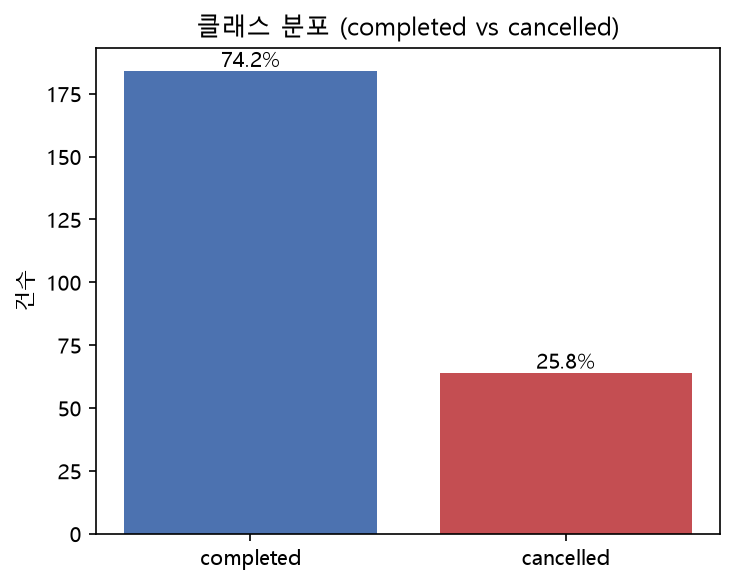

In [7]:
target_distribution = build_target_distribution(model_data)
display(target_distribution)

# 표만 보지 않고, 코드로 직접 막대그래프를 그려서 확인합니다.
from IPython.display import Image

target_distribution_figure_path = plot_target_distribution(target_distribution, figure_dir=REPORT_DIR / "figures")
display(Image(filename=str(target_distribution_figure_path)))


### 실습 4 결과 확인 및 정리

## 클래스 분포
- completed(0): 184건 (74.19%)
- cancelled(1): 64건 (25.81%)
- 불균형 여부: 약 3:1 정도로 완만하지만 뚜렷한 불균형이 있습니다.
- accuracy만으로 판단하기 어려운 이유: "무조건 완료로 찍는" Dummy 모델도 accuracy 74.19%가 나올 수 있는데, 이 모델은 정작 우리가 찾고 싶은 취소 주문은 하나도 못 찾습니다(recall 0%). 그래서 반드시 precision·recall·F1을 같이 봐야 합니다.

뒤 실습에서 실제로 `Dummy Most Frequent`가 Validation에서 accuracy는 그럴듯하게 나오지만 precision/recall/F1이 전부 0인 것을 직접 확인합니다.


## 실습 5. Train / Validation / Test 역할 구분하기

### AI에게 질문

> 클래스 비율을 유지하면서 Train/Validation/Test로 나눠 주세요. Train은 학습, Validation은 모델·threshold 선택, Test는 마지막 평가로 역할을 나눌 겁니다.

### 초보자 상세 설명

Chapter09(회귀, 시간 순서 예측)와 다르게, 이번 가이드는 **stratified random split**을 쓰라고 되어 있었습니다.

> 현재 random split은 교육용입니다. 실제 미래 주문 예측 운영 전에는 out-of-time 평가와 시간 순서 검증이 필요합니다.

이번 실습에서는 3단계로 나눕니다.

- Train = 파라미터 학습
- Validation = 모델 선택 + threshold 선택
- Test = 모든 선택이 끝난 뒤 마지막 평가


In [8]:
train_data, val_data, test_data = split_train_val_test(
    model_data, test_size=0.2, val_size=0.2, random_state=42
)

X_train = train_data[FEATURE_COLUMNS].copy()
X_val = val_data[FEATURE_COLUMNS].copy()
X_test = test_data[FEATURE_COLUMNS].copy()
y_train = train_data[TARGET_COLUMN].copy()
y_val = val_data[TARGET_COLUMN].copy()
y_test = test_data[TARGET_COLUMN].copy()

split_summary = build_split_summary(train_data, val_data, test_data)
display(split_summary)


,split,rows,ratio_pct,cancelled_count,cancelled_pct
0,train,148,59.68,38,25.68
1,validation,50,20.16,13,26.00
2,test,50,20.16,13,26.00


### 실습 5 결과 확인 및 정리

## Train / Validation / Test 분할

| split | rows | ratio_pct | cancelled_count | cancelled_pct |
| --- | ---: | ---: | ---: | ---: |
| train | 148 | 59.68% | 38 | 25.68% |
| validation | 50 | 20.16% | 13 | 26.00% |
| test | 50 | 20.16% | 13 | 26.00% |

세 split 모두 취소 비율이 약 26%로 거의 동일하게 유지된 것을 확인했습니다(stratify 덕분입니다).

### 이번 random split의 교육용 한계
지금은 주문을 무작위로 섞어서 나눴습니다. 실제로 이 모델을 운영에 쓰려면, 실제 서비스에서는 항상 "과거 주문으로 학습해서 미래 주문의 취소 여부를 맞히는" 상황이 되므로, Chapter09처럼 시간 순서 기반의 out-of-time 평가(과거 구간 Train, 최근 구간 Test)가 추가로 필요하다는 것을 기록해 둡니다.


## 실습 6. Pipeline 전처리 확인하기

### AI에게 질문

> 숫자형 feature는 결측치를 중앙값으로 채운 뒤 표준화하고, 범주형 feature는 최빈값으로 채운 뒤 원-핫 인코딩해 주세요. 이 전처리는 Train으로만 학습되어야 합니다.

### 초보자 상세 설명

Chapter09에서 배운 원칙을 그대로 지킵니다. 전처리(`ColumnTransformer`)를 모델과 함께 `Pipeline`으로 묶어서, `Pipeline.fit()`을 호출할 때만 전처리기가 학습되도록 합니다. 이 호출은 항상 Train 위에서만 일어나고, Validation·Test에는 이미 학습된 전처리기의 `transform()`만 적용됩니다.


In [9]:
models = make_classification_models(random_state=42)
print(list(models))
print(models["Random Forest"])


['Dummy Most Frequent', 'Logistic Regression', 'Random Forest']
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['order_month',
                                                   'order_dayofweek', 'age',
                                                   'item_count',
                                                   'total_quantity',
                                                   'order_amount',
                                                   'category_count',
                                                   'customer_tenure_days']),
       

### 실습 6 결과 확인 및 정리

- 숫자형 처리: 결측치 median imputation → `StandardScaler`
- 범주형 처리: 결측치 most_frequent imputation → `OneHotEncoder(handle_unknown="ignore")`
- 전처리 fit 범위: `Pipeline.fit()`이 Train 위에서만 호출되고, Validation·Test에는 `transform()`만 적용됩니다.
- 전체 데이터에 먼저 fit하면 안 되는 이유: Validation·Test의 통계가 미리 전처리에 반영되면, 모델이 실전에서는 알 수 없는 정보를 학습 단계에서 참고하게 되는 leakage가 됩니다.


## 실습 7. Validation에서 후보 모델 비교하기

### AI에게 질문

> Dummy Most Frequent, Logistic Regression, Random Forest를 Train으로 학습하고 Validation에서 Accuracy/Precision/Recall/F1로 비교해 주세요. Test는 아직 보지 않습니다.

### 초보자 상세 설명

가이드에서 순서를 강조했습니다.

> 중요한 점은 Test 결과를 보기 전에 selected_model_name이 결정되어야 한다는 것입니다.

그래서 이 단계에서는 `y_test`가 코드 어디에도 등장하지 않습니다. 비교 기준은 F1 → Recall → Precision 순서입니다.


,model,accuracy,precision,recall,f1
0,Logistic Regression,0.74,0.5,0.230769,0.315789
1,Dummy Most Frequent,0.74,0.0,0.000000,0.000000
2,Random Forest,0.74,0.0,0.000000,0.000000


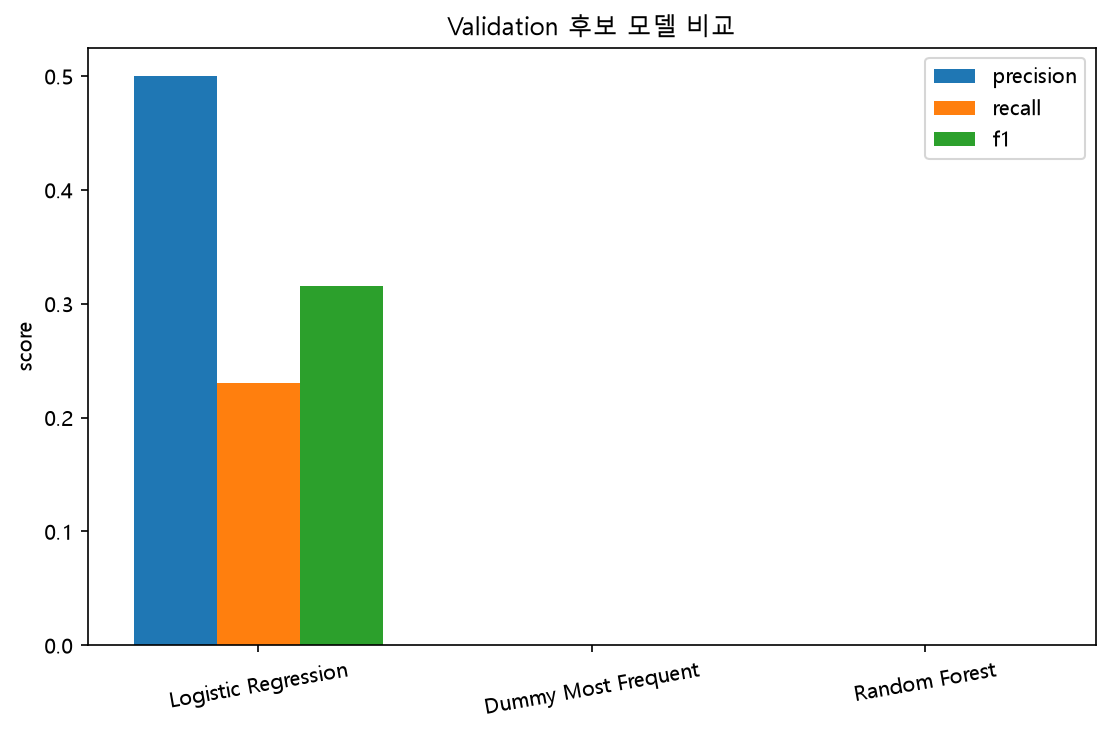

In [10]:
validation_comparison = cross_validate_on_validation(models, X_train, y_train, X_val, y_val)
display(validation_comparison)

# 표만 보지 않고, 코드로 직접 막대그래프를 그려서 확인합니다.
validation_comparison_figure_path = plot_validation_comparison(validation_comparison, figure_dir=REPORT_DIR / "figures")
display(Image(filename=str(validation_comparison_figure_path)))


In [11]:
selected_model_name = select_model_from_validation(validation_comparison)
print("Validation에서 고정한 모델:", selected_model_name)


Validation에서 고정한 모델: Logistic Regression


### 실습 7 결과 확인 및 정리

## Validation 후보 모델 비교

| model | accuracy | precision | recall | f1 |
| --- | ---: | ---: | ---: | ---: |
| Logistic Regression | 0.74 | 0.50 | 0.2308 | 0.3158 |
| Dummy Most Frequent | 0.74 | 0.00 | 0.0000 | 0.0000 |
| Random Forest | 0.74 | 0.00 | 0.0000 | 0.0000 |

이번에도 **Random Forest가 Dummy Baseline과 똑같이 precision/recall/F1이 전부 0**이었습니다. Accuracy만 보면 셋 다 0.74로 그럴듯해 보이지만, Dummy와 Random Forest 둘 다 취소 주문을 단 한 건도 잡아내지 못했다는 뜻입니다. 표본이 148건뿐인 Train으로는 Random Forest(기본 threshold 0.5 기준)가 여전히 "전부 완료로 찍는" 모델과 다르지 않게 학습된 것으로 보입니다. feature를 3개 늘렸다고 이 문제가 저절로 해결되지는 않았습니다.

### Validation으로 선택한 모델
- Selected Model: **Logistic Regression**
- 선택 기준: F1 → Recall → Precision 순으로 비교, 유일하게 0이 아닌 F1(0.3158)을 보임
- Final Test를 보기 전에 선택했는가: **예** (이 시점까지 `y_test`는 코드에 등장하지 않았습니다)


## 실습 8. Validation에서 Threshold 선택하기

### AI에게 질문

> 선택한 Logistic Regression의 Validation 확률을 여러 threshold(0.1~0.9)에서 비교해서, F1 기준으로 가장 좋은 threshold를 골라 주세요.

### 초보자 상세 설명

가이드 설명이 인상 깊었습니다.

> threshold 낮춤 → cancelled 예측 증가 가능 → recall 증가 가능 → FP 증가 가능
> threshold 높임 → cancelled 예측 감소 가능 → precision 증가 가능 → FN 증가 가능

기본값 0.5보다 낮추면 "취소일 가능성이 조금만 있어도 취소 위험으로 분류"하게 되어 더 많은 진짜 취소를 잡아내지만(recall↑), 그만큼 엉뚱하게 취소로 분류되는 완료 주문(FP)도 늘어날 수 있습니다.


,threshold,accuracy,precision,recall,f1
0,0.10,0.44,0.307692,0.923077,0.461538
1,0.15,0.52,0.322581,0.769231,0.454545
2,0.20,0.62,0.384615,0.769231,0.512821
3,0.25,0.62,0.350000,0.538462,0.424242
4,0.30,0.68,0.384615,0.384615,0.384615
5,0.35,0.66,0.333333,0.307692,0.320000
6,0.40,0.68,0.333333,0.230769,0.272727
7,0.45,0.72,0.428571,0.230769,0.300000
8,0.50,0.74,0.500000,0.230769,0.315789
9,0.55,0.74,0.500000,0.153846,0.235294


Validation에서 고정한 threshold: 0.2


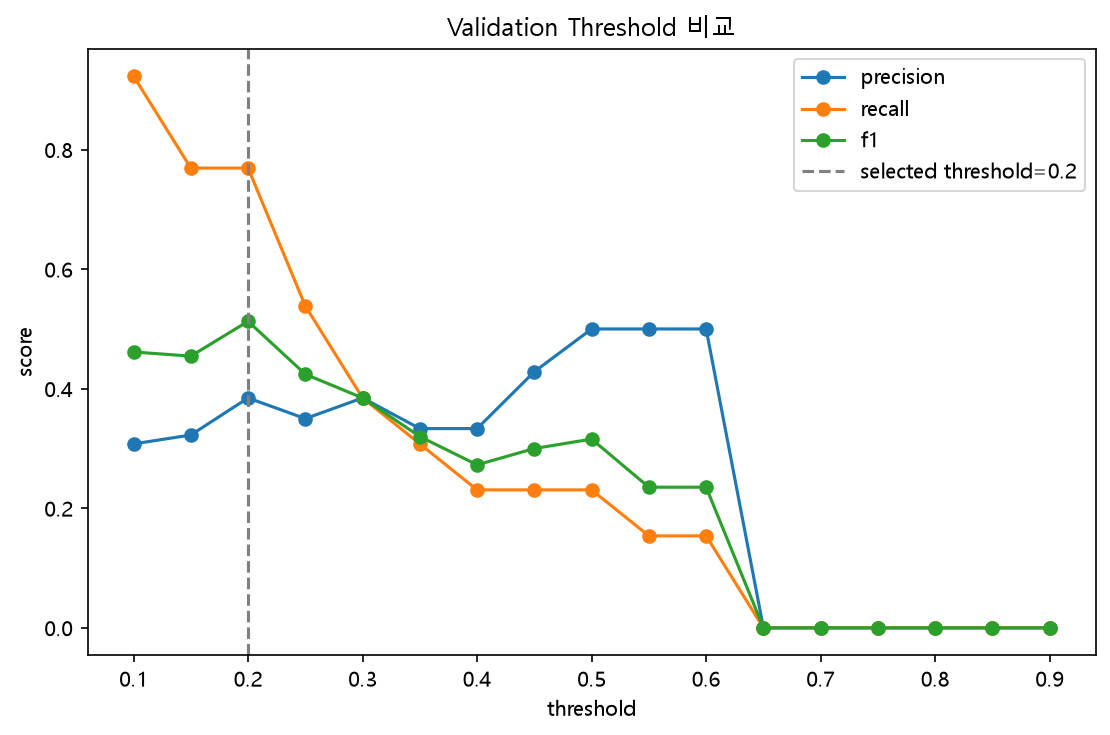

In [12]:
fitted_selected_model = models[selected_model_name]
fitted_selected_model.fit(X_train, y_train)

selected_threshold, threshold_metrics = select_threshold_from_validation(
    fitted_selected_model, X_val, y_val
)
display(threshold_metrics)
print("Validation에서 고정한 threshold:", selected_threshold)

# 표만 보지 않고, precision/recall/f1이 threshold에 따라 어떻게 바뀌는지 실제로 그려봅니다.
threshold_curve_figure_path = plot_threshold_curve(threshold_metrics, selected_threshold, figure_dir=REPORT_DIR / "figures")
display(Image(filename=str(threshold_curve_figure_path)))


### 실습 8 결과 확인 및 정리

## Validation Threshold 비교 (요약)

| threshold | accuracy | precision | recall | f1 |
| --- | ---: | ---: | ---: | ---: |
| 0.10 | 0.44 | 0.3077 | 0.9231 | 0.4615 |
| 0.15 | 0.52 | 0.3226 | 0.7692 | 0.4545 |
| 0.20 | 0.62 | 0.3846 | 0.7692 | **0.5128** |
| 0.25 | 0.62 | 0.3500 | 0.5385 | 0.4242 |
| 0.30 | 0.68 | 0.3846 | 0.3846 | 0.3846 |
| 0.45 | 0.72 | 0.4286 | 0.2308 | 0.3000 |
| 0.50(기본값) | 0.74 | 0.5000 | 0.2308 | 0.3158 |
| 0.55~0.60 | 0.74 | 0.5000 | 0.1538 | 0.2353 |
| 0.65 이상 | 0.72~0.74 | 0.0000 | 0.0000 | 0.0000 |

threshold를 낮출수록 recall이 뚜렷하게 올라가고 precision은 내려가는 것을 표로 직접 확인했습니다. F1 → Recall → Precision 순으로 비교한 결과, **threshold = 0.20**에서 F1이 0.5128로 가장 높게 나왔습니다. 이는 기본값 0.5의 F1(0.3158)보다 훨씬 높은 값입니다.

### 왜 이 threshold를 골랐는가 (업무 목적 관점)
자동 선택 결과(0.2)를 그대로 옮기는 데서 끝내지 않고 생각해봤습니다. 이 모델의 목적이 "취소 위험이 있는 주문을 놓치지 않고 미리 대응하는 것"이라면, precision이 조금 떨어지더라도 recall을 높이는 낮은 threshold가 업무적으로 더 맞는 방향이라고 판단했습니다. 다만 threshold=0.10처럼 극단적으로 낮추면 recall은 92%까지 오르지만 precision이 0.31까지 떨어져서(취소 위험 알림 10건 중 7건이 헛알림) 오히려 신뢰를 잃을 수 있어, F1이 가장 균형 잡힌 0.20을 최종 threshold로 받아들였습니다. FP가 늘어나는 만큼(완료될 주문을 취소 위험으로 잘못 분류) 그 후속 조치(예: 안내 전화, 프로모션)에 드는 비용도 같이 고려해야 한다는 점을 실습 10에서 더 자세히 다룹니다.


## 실습 9. 모델과 Threshold를 고정하고 Final Test 평가하기

### AI에게 질문

> 이제 Final Test를 열어서 Dummy Baseline과 방금 고정한 (Logistic Regression, threshold=0.2)만 평가해 주세요.

### 초보자 상세 설명

여기서 처음으로 Final Test(`y_test`)를 사용합니다. Validation이 끝난 시점에 `selected_model_name`과 `selected_threshold` 두 값이 이미 고정되어 있고, 이제부터는 바뀌지 않습니다.

> Final Test 성능이 기대보다 낮아도 같은 Test를 보면서 모델이나 threshold를 다시 고르지 않습니다.


In [13]:
test_metrics, predictions, probabilities = train_and_evaluate_final(
    models=models,
    selected_model_name=selected_model_name,
    selected_threshold=selected_threshold,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)
display(test_metrics)


,model,selection_role,threshold,accuracy,precision,recall,f1
0,Dummy Most Frequent,baseline,0.5,0.74,0.000000,0.000000,0.000000
1,Logistic Regression,selected_from_validation,0.2,0.58,0.346154,0.692308,0.461538


### 실습 9 결과 확인 및 정리

## Final Test: Baseline vs Frozen Model

| model | selection_role | threshold | accuracy | precision | recall | f1 |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| Dummy Most Frequent | baseline | 0.5 | 0.74 | 0.0000 | 0.0000 | 0.0000 |
| Logistic Regression | selected_from_validation | 0.2 | 0.58 | 0.3462 | 0.6923 | 0.4615 |

### 결과 관찰
Frozen Model의 accuracy(0.58)는 Baseline(0.74)보다 **여전히 낮습니다.** precision·recall·F1은 Baseline이 전부 0인 반면 Frozen Model은 각각 0.35/0.69/0.46로, 취소 주문의 **약 69%**를 찾아냈습니다.

같은 threshold(0.2)의 **Validation** 성능(f1 0.5128)과 **Final Test** 성능(f1 0.4615)을 비교하면, 이번엔 그 차이가 이전(feature 9개 버전, Validation 0.5143 → Test 0.3529)보다 많이 줄었습니다.

### 나의 해석과 판단
feature를 3개(카테고리 다양성, 주요 카테고리, 가입 후 경과일) 추가한 뒤 Final Test F1이 **0.3529 → 0.4615**로 뚜렷하게 개선됐습니다. 특히 recall이 46%→69%로 크게 올라서, 실제 취소 주문을 더 많이 잡아내게 됐습니다. Validation과 Test의 성능 격차도 줄어든 걸 보면, 이번 feature들이 우연한 잡음이 아니라 실제로 취소 여부와 관련 있는 패턴(예: 가입한 지 얼마 안 된 고객, 특정 카테고리 위주의 주문 등)을 담고 있었을 가능성이 있다고 해석했습니다. 다만 여전히 accuracy는 Baseline보다 낮고, 표본도 작아서 "확실히 좋아졌다"고 단정하기보다는 "이 방향의 feature 추가가 도움이 될 수 있다는 근거를 하나 더 얻었다" 정도로 조심스럽게 판단했습니다.

### 업무·분석적 의미
"취소 위험 주문을 미리 찾아내서 대응하는" 목적이라면, feature를 추가한 이 모델이 이전 버전보다 더 쓸모 있어 보입니다. recall 69%는 취소 주문 10건 중 7건 가까이를 미리 찾아낸다는 뜻이고, precision 35%는 취소 위험으로 분류한 주문 중 약 65%가 실제로는 정상 완료된다는 뜻이라, 이 오차 수준이 업무에서 감당 가능한지는 실습 10에서 더 따져봅니다.


## 실습 10. Confusion Matrix와 FP/FN 해석하기

### AI에게 질문

> Frozen Model의 Final Test 결과로 Confusion Matrix를 만들고, FP와 FN 사례를 몇 개 직접 보여 주세요.

### 초보자 상세 설명

네 가지 경우를 구분합니다.

- TN = 완료를 완료로 예측 (맞음)
- FP = 완료를 취소 위험으로 예측 (헛걸음)
- FN = 취소를 완료로 예측 (놓침)
- TP = 취소를 취소 위험으로 예측 (맞음)


,model,cell,count
0,Logistic Regression,TN (완료->완료),20
1,Logistic Regression,FP (완료->취소위험),17
2,Logistic Regression,FN (취소->완료),4
3,Logistic Regression,TP (취소->취소위험),9


predicted,예측: completed(0),예측: cancelled(1)
actual,,
실제: completed(0),20,17
실제: cancelled(1),4,9


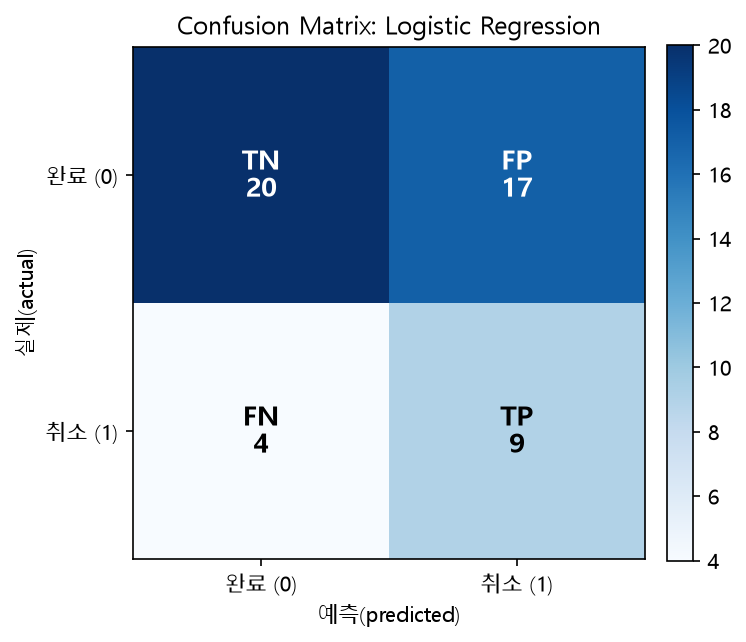


대표 FP 사례 (완료인데 취소 위험으로 예측):


,order_id,actual_is_cancelled,predicted_is_cancelled,cancel_probability,model,threshold,outcome
0,267,0,1,0.4136,Logistic Regression,0.2,FP
1,9,0,1,0.2714,Logistic Regression,0.2,FP



대표 FN 사례 (취소인데 완료로 예측):


,order_id,actual_is_cancelled,predicted_is_cancelled,cancel_probability,model,threshold,outcome
12,292,1,0,0.0518,Logistic Regression,0.2,FN
34,93,1,0,0.0825,Logistic Regression,0.2,FN


In [14]:
confusion = build_confusion_matrix(y_test, predictions[selected_model_name], selected_model_name)
display(confusion)

# 표만 보면 한눈에 안 들어와서, 실제 2x2 매트릭스 모양으로도 만들어 봅니다.
confusion_grid = build_confusion_matrix_grid(y_test, predictions[selected_model_name])
display(confusion_grid)

# 코드로 직접 히트맵을 그려서 확인합니다 (reports/figures/ch10_confusion_matrix.png로도 저장됩니다).
from IPython.display import Image

figure_path = plot_confusion_matrix(
    y_test, predictions[selected_model_name], selected_model_name,
    figure_dir=REPORT_DIR / "figures",
)
display(Image(filename=str(figure_path)))

prediction_result = create_prediction_result(
    test_data=test_data,
    y_test=y_test,
    y_pred=predictions[selected_model_name],
    y_proba=probabilities[selected_model_name],
    model_name=selected_model_name,
    threshold=selected_threshold,
)

print("\n대표 FP 사례 (완료인데 취소 위험으로 예측):")
display(prediction_result[prediction_result["outcome"] == "FP"].head(2))

print("\n대표 FN 사례 (취소인데 완료로 예측):")
display(prediction_result[prediction_result["outcome"] == "FN"].head(2))


### 실습 10 결과 확인 및 정리

## Confusion Matrix (Logistic Regression, threshold=0.2)

위 코드 셀에서 `build_confusion_matrix_grid()`로 실제 2x2 행렬(실제 x 예측) 모양을 만들고, `plot_confusion_matrix()`로 히트맵까지 코드로 직접 그려서 `reports/figures/ch10_confusion_matrix.png`에 저장했습니다.

| cell | count |
| --- | ---: |
| TN (완료→완료) | 20 |
| FP (완료→취소위험) | 17 |
| FN (취소→완료) | 4 |
| TP (취소→취소위험) | 9 |

(TN+FP=37=전체 완료 주문 수, FN+TP=13=전체 취소 주문 수와 정확히 일치합니다.)

feature를 추가하기 전(TN22/FP15/FN7/TP6)과 비교하면, FN(취소인데 완료로 놓친 건수)이 7건→4건으로 줄고 TP(취소를 제대로 잡은 건수)가 6건→9건으로 늘었습니다. 대신 FP(완료인데 취소 위험으로 잘못 분류)는 15건→17건으로 조금 늘었습니다.

### FP가 실제 업무에서 만드는 비용은 무엇인가?
정상적으로 완료될 주문(order_id 267, 9, 52 등)을 취소 위험으로 잘못 분류하면, 불필요하게 안내 연락을 하거나 할인 쿠폰을 보내는 등 헛된 대응 비용이 발생할 수 있습니다.

### FN이 실제 업무에서 만드는 비용은 무엇인가?
실제로 취소될 주문(order_id 292, 93, 128 등)을 완료로 예측해서 놓치면, 미리 대응할 기회를 완전히 놓치게 됩니다. 재고·배송 준비를 그대로 진행하다가 나중에 취소되어 손실이 더 커질 수 있습니다.

### 현재 목적에서는 어느 오류를 더 중요하게 볼 것인가?
"취소 위험을 놓치지 않고 미리 대응"하는 게 목적이라면 FN(취소를 완료로 착각)의 비용이 더 클 가능성이 있다고 생각했습니다. FP는 안내 연락 정도의 비용이지만 FN은 대응 기회 자체를 잃는 것이기 때문입니다. feature를 추가한 뒤 FN이 줄고 TP가 늘어난 것은 이 목적에 정확히 맞는 방향의 개선이었습니다.

### 그 판단을 확정하려면 어떤 업무 정보가 추가로 필요한가?
- 취소 위험 안내에 실제로 드는 비용(FP 1건당 비용)
- 취소를 놓쳤을 때 발생하는 손실(FN 1건당 비용)
이 두 비용을 구체적으로 알아야 "어느 오류가 몇 배 더 나쁜지"를 정확히 계산할 수 있습니다. 지금은 이 수업 데이터만으로 실제 비용을 확정하지 않습니다.


## 실습 11. Internal 결과와 Public 결과 구분하기

### AI에게 질문

> 오류 분석에는 order_id가 필요하지만, 외부에 공개할 결과에는 식별자를 빼 주세요.

### 초보자 상세 설명

방금 실습 10에서 본 `prediction_result`에는 `order_id`가 들어 있어서 특정 주문을 역추적할 수 있습니다. 이건 **Internal(내부 진단용)**으로만 쓰고, 공개용에는 `record_id`(그냥 1부터 매긴 순번)만 남기고 `order_id`를 뺍니다.


In [15]:
public_prediction = public_prediction_result(prediction_result)
display(public_prediction.head())

forbidden_in_public = sorted(set(public_prediction.columns) & (FORBIDDEN_FEATURES | {"order_id", "source_index"}))
print("공개 결과에 남아있는 금지 컬럼:", forbidden_in_public)


,record_id,actual_is_cancelled,predicted_is_cancelled,cancel_probability,model,threshold
0,1,0,1,0.4136,Logistic Regression,0.2
1,2,0,1,0.2714,Logistic Regression,0.2
2,3,0,0,0.1450,Logistic Regression,0.2
3,4,0,1,0.7018,Logistic Regression,0.2
4,5,0,1,0.6851,Logistic Regression,0.2


공개 결과에 남아있는 금지 컬럼: []


### 실습 11 결과 확인 및 정리

- Internal 결과 컬럼: `order_id`, `actual_is_cancelled`, `predicted_is_cancelled`, `cancel_probability`, `model`, `threshold`, `outcome`
- Public 결과 컬럼: `record_id`, `actual_is_cancelled`, `predicted_is_cancelled`, `cancel_probability`, `model`, `threshold` (order_id 없음)
- 공개 결과에 남아있는 금지 컬럼: **없음** (빈 리스트로 확인됨)

`order_id`가 포함된 표는 오류 사례를 직접 들여다볼 때는 필요하지만, 외부에 공개하면 실제 주문을 역추적할 수 있는 식별자가 노출됩니다. 그래서 공개용에는 의미 없는 순번(`record_id`)만 남기기로 했습니다.


## 실습 12. Validation Evidence 확인하기

### AI에게 질문

> 지금까지 지킨 규칙들이 실제로 다 지켜졌는지 자동으로 검사해서 표로 보여 주세요.

### 초보자 상세 설명

`build_classification_validation()`이 이 프로젝트가 정한 핵심 규칙 8개를 코드로 다시 기계적으로 검사합니다. 하나라도 FAIL이면 예외를 던지도록 되어 있어서, 이 셀이 에러 없이 끝났다는 것 자체가 좋은 신호입니다.


In [16]:
validation = build_classification_validation(
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    selected_model_name=selected_model_name,
    selected_threshold=selected_threshold,
    validation_comparison=validation_comparison,
    public_prediction=public_prediction,
)
display(validation)


,check,value,status
0,binary_target_contract,True,PASS
1,forbidden_feature_overlap,0,PASS
2,strict_merge_contract,True,PASS
3,all_splits_have_two_classes,True,PASS
4,selected_model_from_validation,True,PASS
5,selected_threshold_from_validation,0.2,PASS
6,public_prediction_privacy,0,PASS
7,test_rows_for_metrics,50,PASS


### 실습 12 결과 확인 및 정리

## Validation Evidence

| check | value | status |
| --- | --- | --- |
| binary_target_contract | True | PASS |
| forbidden_feature_overlap | 0 | PASS |
| strict_merge_contract | True | PASS |
| all_splits_have_two_classes | True | PASS |
| selected_model_from_validation | True | PASS |
| selected_threshold_from_validation | 0.2 | PASS |
| public_prediction_privacy | 0 | PASS |
| test_rows_for_metrics | 50 | PASS |

8개 항목 모두 PASS였습니다.


## 실습 13. 전체 스크립트 재실행하기

### AI에게 질문

> Notebook 셀 상태에 의존하지 않고, 전체 파이프라인을 스크립트로 처음부터 다시 실행해서 같은 결론이 나오는지 확인하고 싶습니다.

### 초보자 상세 설명

`run_classification_analysis()`는 데이터 로딩부터 Validation Evidence까지 전체 과정을 함수 하나로 다시 실행합니다. 이 결과가 위에서 셀 단위로 실행한 것과 같은지 비교합니다.


In [17]:
result = run_classification_analysis(
    processed_dir=PROCESSED_DIR,
    report_dir=REPORT_DIR,
    test_size=0.2,
    val_size=0.2,
    random_state=42,
)
print("Selected model:", result["selected_model_name"])
print("Selected threshold:", result["selected_threshold"])
display(result["validation"])


Selected model: Logistic Regression
Selected threshold: 0.2


,check,value,status
0,binary_target_contract,True,PASS
1,forbidden_feature_overlap,0,PASS
2,strict_merge_contract,True,PASS
3,all_splits_have_two_classes,True,PASS
4,selected_model_from_validation,True,PASS
5,selected_threshold_from_validation,0.2,PASS
6,public_prediction_privacy,0,PASS
7,test_rows_for_metrics,50,PASS


### 실습 13 결과 확인 및 정리

- 입력 준비/분류 스크립트 실행 성공 여부: 예
- Validation Selected Model: **Logistic Regression** (셀 단위 실행과 동일)
- Validation Selected Threshold: **0.2** (셀 단위 실행과 동일)
- Final Validation 전체 PASS 여부: 예, 8개 항목 모두 PASS
- Notebook과 스크립트 결과의 일관성: `random_state=42`로 고정되어 있어서 완전히 동일한 결과가 재현되었습니다.


## 실습 14. LLM 검토와 최종 사용 판단

### 사용 목적
Target Contract 검토, 주문 단위 feature 설계(추가 feature 3개 포함), Feature Leakage 점검, Validation 기반 모델/threshold 선택 로직 검토, FP/FN 업무 의미 해석에 LLM을 활용했습니다.

### 주요 Prompt 요약
- Target은 completed=0/cancelled=1이고 refunded는 제외
- order_status, is_cancelled, 식별자는 feature에서 제외
- 장바구니 구성(품목 수/수량/금액/카테고리)과 고객 특성은 허용, 단 예측 시점에 실제로 존재하는 값인지 확인
- Train에서 학습, Validation에서만 모델·threshold 선택, Test는 마지막 한 번만
- 전처리는 Pipeline 안에서 Train으로만 학습
- 공개 결과에는 원본 식별자 제거

### LLM 제안 중 수정한 내용
- 처음에는 item_count/total_quantity/order_amount도 "주문 상세에서 나온 값이니 위험하지 않을까" 하고 금지 목록에 넣으려고 했는데, Chapter09와 달리 이번 타깃은 금액이 아니라 취소 여부라서 이 값들은 leakage가 아니라 정상적인 feature라는 걸 다시 확인하고 허용 목록으로 옮겼습니다.
- `customer_tenure_days`를 `order_date - signup_date`로 그냥 계산하려다가, 실제 데이터에서 56건(18.7%)이 가입일이 주문일보다 늦다는 걸 발견하고, 그 경우는 결측으로 남기도록 수정했습니다. LLM이 처음 제안한 "음수면 0으로 클리핑"은 값을 억지로 만드는 것이라 채택하지 않았습니다.
- Random Forest가 Validation에서 Dummy와 똑같이 precision/recall/F1이 0으로 나왔을 때, 순간적으로 "코드에 버그가 있나" 의심했지만, 실제로는 표본이 작은 상태에서 Random Forest가 기본 threshold(0.5)로는 소수 클래스를 전혀 잡아내지 못한 것이었습니다. 다른 모델로 억지로 바꾸지 않고 Logistic Regression을 그대로 선택했습니다.

### 수정 이유
Target이 무엇이냐에 따라 같은 컬럼도 허용/금지가 달라질 수 있다는 것, 날짜 컬럼도 "미래에 생긴 값"이면 leakage가 될 수 있다는 것, 그리고 이상해 보이는 결과(F1=0)도 버그가 아니라 데이터 특성일 수 있다는 것을 실제 수치로 확인한 뒤 판단했습니다.

### 최종 결과를 검증한 방법
`reports/ch10_classification_validation.csv`를 비롯한 Evidence 파일을 직접 확인했고, 셀 단위 실행과 스크립트 재실행 결과가 완전히 같은지도 비교했습니다.

## 최종 사용 판단
- [x] 추가 검증 후 사용 가능

### 판단 근거
1. Baseline(Accuracy만 높고 recall 0) 대비 Logistic Regression은 실제로 취소 주문의 69%를 찾아냈습니다(feature 추가 전 46%보다 개선).
2. precision은 35%로 여전히 낮아서, 취소 위험으로 분류된 주문 중 약 65%는 실제로 정상 완료됩니다.
3. Random split의 교육용 한계(시간 순서 미검증)와 작은 표본(Test 50건, 취소 13건)을 감안하면 지금 수치를 그대로 운영 기준으로 쓰기는 이릅니다.

### 업무적 위험
FP 비용(불필요한 안내/프로모션)과 FN 비용(취소 대응 기회 상실)의 실제 크기를 모른 채 이 threshold를 운영에 바로 적용하면, 의도와 다른 방향으로 자원을 쓸 수 있습니다.

### Random split의 한계
이번 평가는 시간 순서를 고려하지 않은 무작위 분할입니다. 실제 운영 전에는 과거 구간으로 학습해서 최근 구간을 예측하는 out-of-time 검증이 추가로 필요합니다.

### 다음 개선 우선순위
1. FP/FN 각각의 실제 업무 비용을 확인해서 threshold를 다시 조정합니다.
2. 더 많은 주문 데이터를 모아 Random Forest 같은 모델도 안정적으로 평가할 수 있는 표본을 확보합니다.
3. 시간 순서 기반 out-of-time 평가를 추가해서 이번 random split 결과와 비교합니다.


## 최종 체크리스트

- [x] completed=0, cancelled=1만 사용했다.
- [x] refunded와 기타 상태를 타깃 범위에서 제외했다.
- [x] 예측 시점을 설명했다.
- [x] target, ID, 사후 정보를 feature에서 제외했다.
- [x] line_total = quantity × unit_price를 검증했다.
- [x] 주문 단위 특징과 병합 관계를 검증했다.
- [x] 클래스 비율을 확인했다.
- [x] Dummy baseline과 비교했다.
- [x] Train / Validation / Test 역할을 구분했다.
- [x] 전처리를 Pipeline 안에서 Train으로 학습했다.
- [x] 모델을 Validation에서 선택했다.
- [x] Threshold를 Validation에서 선택했다.
- [x] Final Test 전에 선택을 고정했다.
- [x] Accuracy, Precision, Recall, F1을 함께 해석했다.
- [x] FP/FN 업무적 의미를 작성했다.
- [x] 공개 결과에 원본 식별자가 없는지 확인했다.
- [x] Validation Evidence를 확인했다.
- [x] Random split의 교육용 한계를 기록했다.
- [x] 최종 사용 판단과 한계를 작성했다.
- [ ] GitHub에서 Notebook 렌더링을 확인한다. (제출 직전)
- [ ] 최종 Notebook 파일 URL을 제출한다. (제출 직전)


## Chapter 10 한 문장 정리

**모델과 Threshold 선택은 Validation에서 끝내고, Final Test는 그 선택이 끝난 뒤 마지막 평가에만 사용합니다.** 이번 실습에서는 accuracy만 보면 Baseline보다 낮아 보이는 모델을, precision·recall·F1과 FP/FN의 실제 의미까지 함께 봐야만 "그래도 쓸모가 있다"는 걸 확인할 수 있었습니다. 정답 하나를 맞히는 것보다, 왜 그 선택을 했고 무엇을 아직 모르는지를 설명할 수 있는 것이 이번 장의 핵심이었습니다.
